<a href="https://colab.research.google.com/github/legendofzer0/imdb_sentiment_analysis_demo_practice/blob/main/Sentiment_Analysis_on_Movie_Reviews_using_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Analysis on Movie Reviews using Logistic Regression

Classify reviews as positive or negative using traditional ML (Supervised Learning)

Importing Kaggle  dataset

In [12]:
from google.colab import files
files.upload()

import shutil
import os

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

!pip install -q kaggle
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip -q imdb-dataset-of-50k-movie-reviews.zip



Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)
replace IMDB Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

converting to dataframe and ch

In [28]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")
df.head()
# df.info()
X=df['review']
y= df['sentiment']

Preprocing the text

In [24]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stop_words= set(stopwords.words('english'))
stemmer= PorterStemmer()

def clean_words(text):
  text = re.sub("<.*?>",'',text)
  test = re.sub("[^a-zA-Z]"," ",text)
  text = text.lower().split()
  text = [stemmer.stem(word) for word in text if word not in stop_words]
  return ''.join(text)

df['clean_review'] = X.apply(clean_words)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,"onereviewmentionwatch1ozepisodhooked.right,exa..."
1,A wonderful little production. <br /><br />The...,positive,wonderlittlproduction.filmtechniquunassuming-o...
2,I thought this was a wonderful way to spend ti...,positive,"thoughtwonderwayspendtimehotsummerweekend,sita..."
3,Basically there's a family where a little boy ...,negative,basicthere'famililittlboy(jake)thinkthere'zomb...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"pettermattei'""lovetimemoney""visualstunfilmwatc..."


Tokenizing data

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X=df['clean_review']
y= df['sentiment'].map({'positive':1,'negative':0 })

vectorizer = TfidfVectorizer(max_features=5000)
X_vec= vectorizer.fit_transform(X)

Spliting data

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X_vec,y,test_size=0.3,random_state=50)


train model

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

logReg = LogisticRegression()
logReg.fit(X_train,y_train)
y_prediction= logReg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_prediction))
print(classification_report(y_test, y_prediction))

Accuracy: 0.7108666666666666
              precision    recall  f1-score   support

           0       0.74      0.66      0.70      7571
           1       0.69      0.76      0.72      7429

    accuracy                           0.71     15000
   macro avg       0.71      0.71      0.71     15000
weighted avg       0.71      0.71      0.71     15000



Visualization

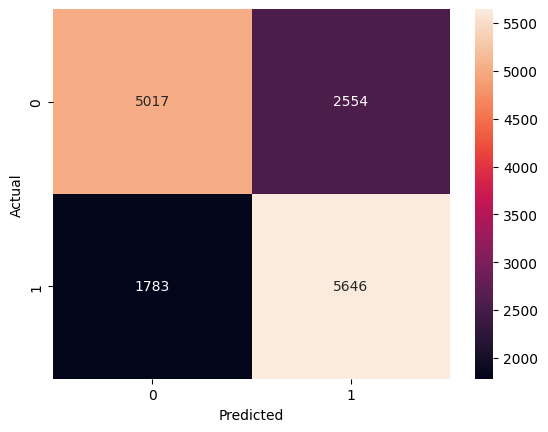

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test,y_prediction),annot=True,fmt="d",color="Red")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



***Findings***

As we can see in the heatmap


1 is Positive
0 is Negative

High accuracy can be seen of 71%

with a high presion, recall adn f1 score